# UCCSD–VQE for the Pairing Hamiltonian — from a single pair basis to a scalable, Trotterised solver

**Exact diagonalisation, classical CCD, and a Trotterised UCCSD variational quantum eigensolver, for $N$ fermions in $k$ doubly-degenerate levels**

This notebook studies the constant-pairing model of `week47.ipynb` from teh course FYS4480 Many-body Physics from university of Oslo with three independent
methods and compares them across the pairing strength $g$, the number of levels $k$, and
the particle number $N$:

1. **Exact diagonalisation** — in the seniority-zero pair basis (the reference of
   `week47.ipynb`) and, equivalently, as full configuration interaction (FCI) in the
   $N$-particle sector.
2. **Coupled-cluster doubles (CCD)** — the classical solver of `week47.ipynb`.
3. **UCCSD–VQE** — a variational quantum eigensolver built *along the lines of* the
   Coulomb-interaction notebook (`qdresrefinement_vqe_K12.ipynb`): Jordan–Wigner mapping,
   a unitary coupled-cluster ansatz, and gradient-based optimisation.

The VQE is implemented **the way it runs on a quantum computer — as a Trotterised
product of elementary unitaries**.  This single idea lets the same code run from the
tiny $k=2$ basis (a single Slater determinant) all the way to $k=8$ (16 qubits), and for
any even particle number $N$.  We begin pedagogically at $k=2,3,4$ with $N=4$, then scale
up.

The story in one line: *exact diagonalisation and CCD set the references; the Trotterised
UCCSD–VQE reproduces them for small bases and remains a tight, variational solver as the
basis grows. These notes are based on codes and lecture notes from several courses, FYS4480 Many-body Physics and FYS5419 Quantum Computing and Quantum ML and Lecture Notes in Physics 938, chapter 8*

---
## 1  The pairing Hamiltonian

We use the constant-pairing Hamiltonian of *Lecture Notes in Physics* **936**, Chapter 8
— the same convention as `week47.ipynb`:

$$
\hat H \;=\; \delta\sum_{p=0}^{k-1}\, p \sum_{\sigma=\uparrow,\downarrow}
              \hat a^{\dagger}_{p\sigma}\hat a_{p\sigma}
       \;-\;\frac{g}{2}\sum_{p,q=0}^{k-1}
              \hat a^{\dagger}_{p\uparrow}\hat a^{\dagger}_{p\downarrow}
              \hat a_{q\downarrow}\hat a_{q\uparrow}.
$$

There are $k$ doubly-degenerate levels and $N$ fermions ($N$ even, $P=N/2$ pairs).  Level
$p$ has single-particle energy $\delta p$ (we set $\delta=1$) and holds one spin-up and
one spin-down fermion; the interaction moves a singlet pair from level $q$ to level $p$
with constant strength $-g/2$.

### Pair operators and seniority

With the **pair-creation operator** $\hat A^{\dagger}_p=\hat a^{\dagger}_{p\uparrow}
\hat a^{\dagger}_{p\downarrow}$ the interaction is $\hat V=-\tfrac{g}{2}\sum_{p,q}\hat
A^{\dagger}_p\hat A_q$.  Both terms conserve the **seniority** $\nu$ (number of unpaired
fermions); the attractive force keeps the ground state at $\nu=0$, so every fermion sits
in a pair and $S=0$.  A seniority-zero state is fixed by the set of doubly-occupied
levels, $|\{p_1,\dots,p_P\}\rangle=\hat A^{\dagger}_{p_1}\cdots\hat A^{\dagger}_{p_P}|0\rangle$.

The **Hartree–Fock reference** fills the $P$ lowest levels, with energy
$$
E_{\rm HF}(N,g)=2\delta\sum_{p=0}^{P-1}p-\frac{g}{2}P=\delta\,P(P-1)-\frac{g}{2}P,
$$
which for $N=4$ ($P=2$) is the familiar $E_{\rm HF}=2\delta-g$.

| $k$ | levels | seniority-0 dim $\binom{k}{P}$ (N=4) | character |
|----:|:------|:-----:|:----------|
| 2 | $0,1$ | 1 | both pairs in the two lowest levels — the **Hartree–Fock** determinant |
| 3 | $0,1,2$ | 3 | one extra level |
| 4 | $0,1,2,3$ | 6 | the full `week47.ipynb` model |
| $\vdots$ | | | |
| 8 | $0,\dots,7$ | 28 | 16 qubits — reached by the Trotterised solver |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from itertools import combinations
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import eigsh
from scipy.optimize import minimize

DELTA = 1.0    # single-particle level spacing

def E_HF(N, g, delta=DELTA):
    """Hartree-Fock (reference) energy for N fermions = P pairs in the lowest P levels."""
    P = N // 2
    return 2.0*delta*sum(range(P)) - 0.5*g*P

print("Pairing model:  delta =", DELTA)
print("seniority-zero pair-basis dimension  C(k, N/2):")
for N in (2, 4, 6):
    dims = "   ".join(f"k={k}:{len(list(combinations(range(k), N//2)))}" for k in (2,3,4,6,8))
    print(f"  N={N} ({N//2} pairs):  {dims}")

Pairing model:  delta = 1.0
seniority-zero pair-basis dimension  C(k, N/2):
  N=2 (1 pairs):  k=2:2   k=3:3   k=4:4   k=6:6   k=8:8
  N=4 (2 pairs):  k=2:1   k=3:3   k=4:6   k=6:15   k=8:28
  N=6 (3 pairs):  k=2:0   k=3:1   k=4:4   k=6:20   k=8:56


---
## 2  Qubit encoding: Jordan–Wigner, in two complementary representations

Each spin-orbital becomes one qubit; with $k$ levels there are $2k$ qubits, ordered as
$\text{qubit}=2p+\sigma$ ($\sigma=0\!\uparrow,\,1\!\downarrow$), so level $p$ occupies
qubits $2p,2p+1$.  Fermionic operators use the Jordan–Wigner string
$\hat a^{\dagger}_j=\big(\bigotimes_{l<j}Z_l\big)\tfrac{X_j-iY_j}{2}$.

We use **two equivalent representations** of the same physics:

* a **dense** one — the explicit $2^{2k}\times2^{2k}$ Pauli matrices, perfect for seeing
  the qubit Hamiltonian and for small $k$ ($k\le4$);
* a **Fock-basis (bitstring)** one — each Slater determinant is an integer, operators act
  by bit manipulation with a Jordan–Wigner sign, and we stay inside the fixed-$N$ sector
  of dimension $\binom{2k}{N}$.  This is what lets us reach $k=8$ (16 qubits), where the
  dense $2^{16}\times2^{16}$ matrix would be hopeless.

In [2]:
# ---- (a) dense Jordan-Wigner operators (pedagogical, small k) ----
I2 = np.eye(2, dtype=complex)
X  = np.array([[0,1],[1,0]], complex); Y = np.array([[0,-1j],[1j,0]], complex)
Z  = np.array([[1,0],[0,-1]], complex)
def kron_n(*ops):
    r = ops[0]
    for o in ops[1:]: r = np.kron(r, o)
    return r
def jw_create(j, n):
    return kron_n(*[Z if l<j else ((X-1j*Y)/2 if l==j else I2) for l in range(n)])
def jw_annihilate(j, n): return jw_create(j, n).conj().T
def number_op(j, n):     return jw_create(j, n) @ jw_annihilate(j, n)

# ---- (b) Fock-basis bitstring helpers (scalable) ----
def _bit(s, j, n):  return (s >> (n-1-j)) & 1          # is qubit j occupied in state s?
def _flip(s, j, n): return s ^ (1 << (n-1-j))          # create/annihilate at qubit j
def _jw_sign(s, j, n):
    """Jordan-Wigner sign: (-1)^(occupied qubits before position j)."""
    c = 0
    for q in range(j):
        if (s >> (n-1-q)) & 1: c += 1
    return 1 - 2*(c % 2)

def build_sector(k, N):
    """Computational-basis states (as integers) of the N-particle sector on 2k qubits."""
    nq = 2*k
    states = sorted(sum(1 << (nq-1-j) for j in c) for c in combinations(range(nq), N))
    return nq, states, {s: i for i, s in enumerate(states)}

print("Fixed-N sector dimension  C(2k, N):")
for k in (2,3,4,5,6,7,8):
    print(f"  k={k:2d} ({2*k:2d} qubits):  "
          + "  ".join(f"N={N}:{len(build_sector(k,N)[1]):5d}" for N in (2,4,6)))

Fixed-N sector dimension  C(2k, N):
  k= 2 ( 4 qubits):  N=2:    6  N=4:    1  N=6:    0
  k= 3 ( 6 qubits):  N=2:   15  N=4:   15  N=6:    1
  k= 4 ( 8 qubits):  N=2:   28  N=4:   70  N=6:   28
  k= 5 (10 qubits):  N=2:   45  N=4:  210  N=6:  210
  k= 6 (12 qubits):  N=2:   66  N=4:  495  N=6:  924
  k= 7 (14 qubits):  N=2:   91  N=4: 1001  N=6: 3003
  k= 8 (16 qubits):  N=2:  120  N=4: 1820  N=6: 8008


---
## 3  Exact diagonalisation and full FCI

### Seniority-zero pair basis (the `week47.ipynb` reference)

In the no-broken-pair basis a two-pair state $|D\rangle=|\{p_1,p_2\}\rangle$ has
$\langle D|\hat H|D\rangle=2\delta\sum_{p\in D}p-g$ and $\langle D'|\hat H|D\rangle=-g/2$
when $D'$ differs from $D$ by one pair move (zero otherwise).  For $k=4$ this is the
$6\times6$ matrix of `week47.ipynb`.

In [3]:
def pairing_seniority0_H(k, g, N, delta=DELTA):
    """Pairing Hamiltonian in the seniority-zero basis (tuples of occupied levels)."""
    P = N//2
    basis = list(combinations(range(k), P)); idx = {s:i for i,s in enumerate(basis)}
    H = np.zeros((len(basis), len(basis)))
    for i, occ in enumerate(basis):
        H[i, i] = 2.0*delta*sum(occ) - 0.5*g*P
        so = set(occ)
        for pout in occ:
            for pin in range(k):
                if pin in so: continue
                H[i, idx[tuple(sorted(so-{pout}|{pin}))]] += -0.5*g
    return H, basis

print("Exact diagonalisation in the seniority-zero (S=0) sector,  delta=1, g=1, N=4")
print("="*72)
exact_g1 = {}
for k in (2, 3, 4):
    H, basis = pairing_seniority0_H(k, 1.0, 4)
    ev = np.linalg.eigvalsh(H); exact_g1[k] = ev
    print(f"\nk={k}  dim={len(basis)}  occupied-level basis: {basis}")
    if k == 4:
        print("  H =")
        for row in H: print("     " + "  ".join(f"{v:+5.2f}" for v in row))
    print(f"  E0 = {ev[0]:+.6f}   E_HF = {E_HF(4,1.0):+.4f}   E_corr = {ev[0]-E_HF(4,1.0):+.6f}")

Exact diagonalisation in the seniority-zero (S=0) sector,  delta=1, g=1, N=4

k=2  dim=1  occupied-level basis: [(0, 1)]
  E0 = +1.000000   E_HF = +1.0000   E_corr = +0.000000

k=3  dim=3  occupied-level basis: [(0, 1), (0, 2), (1, 2)]
  E0 = +0.794697   E_HF = +1.0000   E_corr = -0.205303

k=4  dim=6  occupied-level basis: [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]
  H =
     +1.00  -0.50  -0.50  -0.50  -0.50  +0.00
     -0.50  +3.00  -0.50  -0.50  +0.00  -0.50
     -0.50  -0.50  +5.00  +0.00  -0.50  -0.50
     -0.50  -0.50  +0.00  +5.00  -0.50  -0.50
     -0.50  +0.00  -0.50  -0.50  +7.00  -0.50
     +0.00  -0.50  -0.50  -0.50  -0.50  +9.00
  E0 = +0.635548   E_HF = +1.0000   E_corr = -0.364452


The $k=4$ matrix reproduces exactly the $6\times6$ array of `week47.ipynb` (diagonal
$2\!-\!g,4\!-\!g,6\!-\!g,6\!-\!g,8\!-\!g,10\!-\!g$, off-diagonal $-g/2$).  Enlarging the
basis lowers the ground state below $E_{\rm HF}=2-g$; the difference is the correlation
energy.

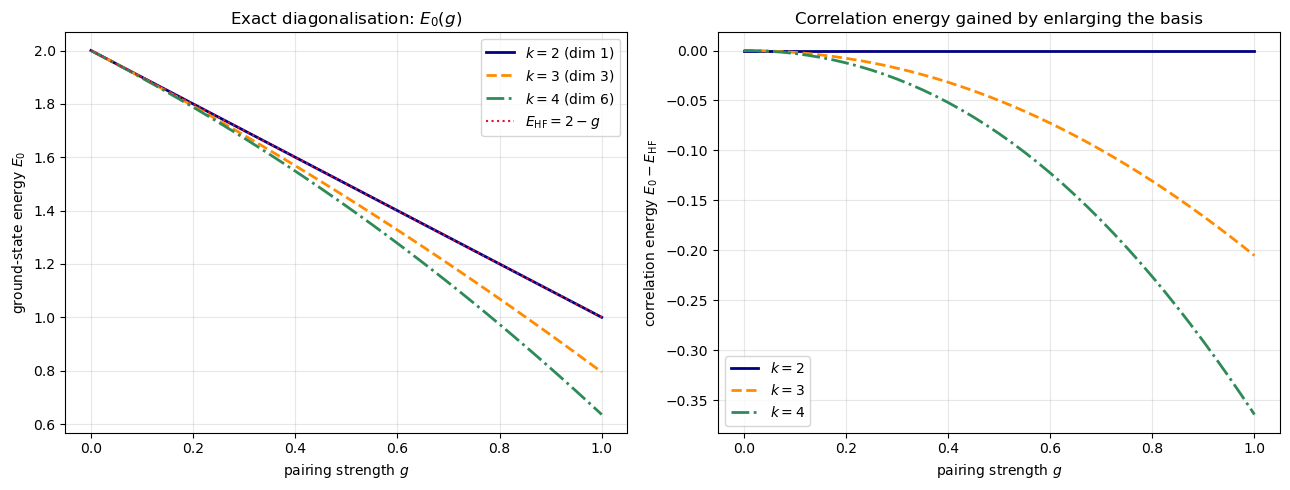

In [4]:
# Correlation energy vs g (exact), the analogue of the week47 plot, for k=2,3,4 (N=4)
g_vals = np.linspace(0.0, 1.0, 41)
E0_exact = {k: np.array([np.linalg.eigvalsh(pairing_seniority0_H(k, g, 4)[0])[0] for g in g_vals])
            for k in (2,3,4)}
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 5))
styles = {2:('navy','-'), 3:('darkorange','--'), 4:('seagreen','-.')}
for k,(c,ls) in styles.items():
    axA.plot(g_vals, E0_exact[k], color=c, ls=ls, lw=2,
             label=f'$k={k}$ (dim {len(list(combinations(range(k),2)))})')
axA.plot(g_vals, E_HF(4, g_vals), color='crimson', ls=':', lw=1.5, label=r'$E_{\rm HF}=2-g$')
axA.set_xlabel('pairing strength $g$'); axA.set_ylabel(r'ground-state energy $E_0$')
axA.set_title('Exact diagonalisation: $E_0(g)$'); axA.legend(); axA.grid(alpha=0.3)
for k,(c,ls) in styles.items():
    axB.plot(g_vals, E0_exact[k]-E_HF(4, g_vals), color=c, ls=ls, lw=2, label=f'$k={k}$')
axB.set_xlabel('pairing strength $g$'); axB.set_ylabel(r'correlation energy $E_0-E_{\rm HF}$')
axB.set_title('Correlation energy gained by enlarging the basis'); axB.legend(); axB.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Full FCI in the $N$-particle sector — and why it equals the seniority-zero result

Building $\hat H$ as a sparse matrix in the Fock basis lets us diagonalise the *full*
$N$-particle problem (all determinants, broken pairs included) and reach large $k$.  The
ground state has no broken pairs, so this **full FCI coincides with the seniority-zero
result** — we verify it for $k=2,\dots,8$, and also check the explicit dense
Jordan–Wigner Hamiltonian for the small cases.

In [5]:
def H_pairing_sparse(k, g, N, states, index, delta=DELTA):
    """Pairing Hamiltonian as a sparse matrix in the N-particle sector (bitstring action)."""
    nq = 2*k; M = len(states); gh = -0.5*g
    rows, cols, vals = [], [], []
    for I in states:
        a = index[I]; rows.append(a); cols.append(a)
        vals.append(sum(delta*(j//2) for j in range(nq) if _bit(I, j, nq)))     # one-body
        for p in range(k):                                                      # -g/2 A_p^dag A_q
            for q in range(k):
                r0, r1 = 2*q, 2*q+1; c0, c1 = 2*p, 2*p+1
                if not _bit(I, r0, nq): continue
                s1 = _jw_sign(I, r0, nq); t = _flip(I, r0, nq)
                if not _bit(t, r1, nq): continue
                s2 = _jw_sign(t, r1, nq); t = _flip(t, r1, nq)
                if _bit(t, c1, nq): continue
                s3 = _jw_sign(t, c1, nq); t = _flip(t, c1, nq)
                if _bit(t, c0, nq): continue
                s4 = _jw_sign(t, c0, nq); J = _flip(t, c0, nq)
                rows.append(index[J]); cols.append(a); vals.append(gh*s1*s2*s3*s4)
    H = csr_matrix((vals, (rows, cols)), shape=(M, M))
    return (H + H.T)*0.5

def fci_ground(H):
    M = H.shape[0]
    if M == 1:    return float(H[0, 0])
    if M <= 1500: return float(np.linalg.eigvalsh(H.toarray())[0])
    return float(eigsh(H, k=1, which='SA', maxiter=5000)[0][0])

def dense_jw_fci(k, g, N):
    """Explicit dense 2^(2k) Jordan-Wigner Hamiltonian; FCI in the N-sector (small k only)."""
    nq, dim = 2*k, 2**(2*k)
    Hk = sum(DELTA*(so//2)*number_op(so, nq) for so in range(nq))
    W = sum(jw_create(2*p,nq)@jw_create(2*p+1,nq)@jw_annihilate(2*q+1,nq)@jw_annihilate(2*q,nq)
            for p in range(k) for q in range(k))
    H = np.real(Hk - 0.5*g*W); H = (H+H.T)/2
    occ = [sum(1<<(nq-1-j) for j in c) for c in combinations(range(nq), N)]
    return np.linalg.eigvalsh(H[np.ix_(occ, occ)])[0]

print("Full FCI (N=4) : sparse N-sector vs seniority-zero vs dense Jordan-Wigner")
print("="*72)
for k in (2,3,4,5,6,7,8):
    nq, states, index = build_sector(k, 4)
    e_fci = fci_ground(H_pairing_sparse(k, 1.0, 4, states, index))
    e_sen = np.linalg.eigvalsh(pairing_seniority0_H(k, 1.0, 4)[0])[0]
    extra = f"  E_denseJW={dense_jw_fci(k,1.0,4):+.6f}" if k <= 4 else ""
    print(f"  k={k}: dim(N=4)={len(states):5d}  E_FCI={e_fci:+.6f}  E_sen0={e_sen:+.6f}"
          f"  diff={e_fci-e_sen:+.1e}{extra}")

Full FCI (N=4) : sparse N-sector vs seniority-zero vs dense Jordan-Wigner
  k=2: dim(N=4)=    1  E_FCI=+1.000000  E_sen0=+1.000000  diff=+0.0e+00  E_denseJW=+1.000000
  k=3: dim(N=4)=   15  E_FCI=+0.794697  E_sen0=+0.794697  diff=+1.1e-16  E_denseJW=+0.794697
  k=4: dim(N=4)=   70  E_FCI=+0.635548  E_sen0=+0.635548  diff=-1.1e-16  E_denseJW=+0.635548
  k=5: dim(N=4)=  210  E_FCI=+0.497768  E_sen0=+0.497768  diff=+2.2e-16
  k=6: dim(N=4)=  495  E_FCI=+0.372664  E_sen0=+0.372664  diff=-4.1e-15
  k=7: dim(N=4)= 1001  E_FCI=+0.256052  E_sen0=+0.256052  diff=+1.2e-14
  k=8: dim(N=4)= 1820  E_FCI=+0.145559  E_sen0=+0.145559  diff=-3.1e-15


  k=4: dim(N=4)=   70  E_FCI=+0.635548  E_sen0=+0.635548  diff=+8.4e-15  E_denseJW=+0.635548
  k=5: dim(N=4)=  210  E_FCI=+0.497768  E_sen0=+0.497768  diff=-2.6e-15
  k=6: dim(N=4)=  495  E_FCI=+0.372664  E_sen0=+0.372664  diff=-2.1e-14
  k=7: dim(N=4)= 1001  E_FCI=+0.256052  E_sen0=+0.256052  diff=+9.0e-15


  k=8: dim(N=4)= 1820  E_FCI=+0.145559  E_sen0=+0.145559  diff=-2.8e-16


All three constructions agree.  The dense Jordan–Wigner matrix is transparent but
costs $2^{2k}$; from here on the sparse fixed-$N$ representation does the heavy lifting,
which is what makes $k=8$ feasible.

---
## 4  Classical coupled-cluster doubles (CCD)

`week47.ipynb` solves the pairing problem with the classical **coupled-cluster doubles**
equations of *LNP 936*, Chapter 8.  Singles vanish identically for the pairing force in a
Hartree–Fock basis (Section 5), so CCD already carries the full singles-and-doubles
content.  We keep that solver and generalise the hole/particle counts to any $(k,N)$:
holes $=N$, particles $=2k-N$ (for $k$ with $2k>N$).  CCD is non-variational and provides
the second comparison curve.

In [6]:
def init_pairing_v(g, pnum, hnum):
    v_pppp = np.zeros((pnum,)*4); v_pphh = np.zeros((pnum,pnum,hnum,hnum)); v_hhhh = np.zeros((hnum,)*4)
    gv = -0.5*g
    for a in range(0,pnum,2):
        for b in range(0,pnum,2):
            v_pppp[a,a+1,b,b+1]=gv; v_pppp[a+1,a,b,b+1]=-gv; v_pppp[a,a+1,b+1,b]=-gv; v_pppp[a+1,a,b+1,b]=gv
    for a in range(0,pnum,2):
        for i in range(0,hnum,2):
            v_pphh[a,a+1,i,i+1]=gv; v_pphh[a+1,a,i,i+1]=-gv; v_pphh[a,a+1,i+1,i]=-gv; v_pphh[a+1,a,i+1,i]=gv
    for j in range(0,hnum,2):
        for i in range(0,hnum,2):
            v_hhhh[j,j+1,i,i+1]=gv; v_hhhh[j+1,j,i,i+1]=-gv; v_hhhh[j,j+1,i+1,i]=-gv; v_hhhh[j+1,j,i+1,i]=gv
    return v_pppp, v_pphh, v_hhhh

def init_pairing_fock(delta, g, pnum, hnum):
    dv, gv = 0.5*delta, -0.5*g; f_pp = np.zeros((pnum,pnum)); f_hh = np.zeros((hnum,hnum))
    for i in range(0,hnum,2): f_hh[i,i]=dv*i+gv; f_hh[i+1,i+1]=dv*i+gv
    for a in range(0,pnum,2): f_pp[a,a]=dv*(hnum+a); f_pp[a+1,a+1]=dv*(hnum+a)
    return f_pp, f_hh

def _t2_den(f_pp, f_hh, t):
    pn, hn = len(f_pp), len(f_hh); out = np.zeros_like(t)
    for i in range(hn):
        for j in range(hn):
            for a in range(pn):
                for b in range(pn):
                    out[a,b,i,j] = t[a,b,i,j]/(f_hh[i,i]+f_hh[j,j]-f_pp[a,a]-f_pp[b,b])
    return out

def ccd_iter(v_pppp, v_pphh, v_hhhh, f_pp, f_hh, t2):
    Hb = ( v_pphh + np.einsum('bc,acij->abij',f_pp,t2) - np.einsum('ac,bcij->abij',f_pp,t2)
         - np.einsum('abik,kj->abij',t2,f_hh) + np.einsum('abjk,ki->abij',t2,f_hh)
         + 0.5*np.einsum('abcd,cdij->abij',v_pppp,t2) + 0.5*np.einsum('abkl,klij->abij',t2,v_hhhh) )
    chh = 0.5*np.einsum('cdkl,cdjl->kj',v_pphh,t2)
    Hb -= (np.einsum('abik,kj->abij',t2,chh) - np.einsum('abik,kj->abji',t2,chh))
    cpp = -0.5*np.einsum('cdkl,bdkl->cb',v_pphh,t2)
    Hb += (np.einsum('acij,cb->abij',t2,cpp) - np.einsum('acij,cb->baij',t2,cpp))
    chhhh = 0.5*np.einsum('cdkl,cdij->klij',v_pphh,t2)
    Hb += 0.5*np.einsum('abkl,klij->abij',t2,chhhh)
    cphph = 0.5*np.einsum('cdkl,dblj->bkcj',v_pphh,t2)
    Hb += ( np.einsum('bkcj,acik->abij',cphph,t2) - np.einsum('bkcj,acik->baij',cphph,t2)
          - np.einsum('bkcj,acik->abji',cphph,t2) + np.einsum('bkcj,acik->baji',cphph,t2) )
    return t2 + _t2_den(f_pp, f_hh, Hb)

def run_ccd(k, g, N, delta=DELTA, niter=300, mix=0.5, tol=1e-13):
    """Total CCD energy and correlation energy for the pairing model."""
    hnum, pnum = N, 2*k-N; Eref = E_HF(N, g, delta)
    if pnum == 0: return Eref, 0.0
    v_pppp, v_pphh, v_hhhh = init_pairing_v(g, pnum, hnum)
    f_pp, f_hh = init_pairing_fock(delta, g, pnum, hnum)
    t2 = _t2_den(f_pp, f_hh, v_pphh.copy()); erg = 0.25*np.einsum('abij,abij',v_pphh,t2)
    for _ in range(niter):
        t2n = ccd_iter(v_pppp, v_pphh, v_hhhh, f_pp, f_hh, t2)
        ergn = 0.25*np.einsum('abij,abij',v_pphh,t2n); t2 = mix*t2n + (1-mix)*t2
        if abs(ergn-erg) < tol: erg = ergn; break
        erg = ergn
    return Eref + erg, erg

print("Coupled-cluster doubles (CCD) vs exact diagonalisation,  g = 1, N = 4")
print("="*64)
for k in (2,3,4):
    Etot, Ecorr = run_ccd(k, 1.0, 4); E0 = exact_g1[k][0]
    print(f"  k={k}:  E_CCD={Etot:+.6f} (corr {Ecorr:+.6f})   E_exact={E0:+.6f}   diff={Etot-E0:+.2e}")

Coupled-cluster doubles (CCD) vs exact diagonalisation,  g = 1, N = 4
  k=2:  E_CCD=+1.000000 (corr +0.000000)   E_exact=+1.000000   diff=+0.00e+00
  k=3:  E_CCD=+0.794697 (corr -0.205303)   E_exact=+0.794697   diff=+1.42e-13
  k=4:  E_CCD=+0.630443 (corr -0.369557)   E_exact=+0.635548   diff=-5.11e-03


---
## 5  UCCSD ansatz and the variational quantum eigensolver — with Trotterisation

The trial state is the **unitary coupled-cluster singles-and-doubles** wavefunction,
written as a *product* of elementary unitaries built from number-conserving fermionic
excitation generators $\hat\tau_\mu-\hat\tau_\mu^{\dagger}$ acting on the Hartree–Fock
reference:

$$
|\Psi(\boldsymbol\theta)\rangle=
\Big[\prod_{\mu\in\rm D}e^{\theta_\mu(\hat\tau_\mu-\hat\tau_\mu^{\dagger})}\Big]
\Big[\prod_{\nu\in\rm S}e^{\theta_\nu(\hat\tau_\nu-\hat\tau_\nu^{\dagger})}\Big]
|\Phi_{\rm HF}\rangle ,
$$

* **singles** $\hat\tau^{a}_{i}=\hat a^{\dagger}_a\hat a_i$ (spin conserving),
* **doubles** $\hat\tau^{ab}_{ij}=\hat a^{\dagger}_a\hat a^{\dagger}_b\hat a_j\hat a_i$
  ($N$- and $S_z$-conserving), $i<j$ occupied, $a<b$ virtual.

Writing the exponential of the *sum* of generators as a *product* of single-generator
exponentials is exactly **first-order Trotterisation** — and it is how the ansatz is
applied on a quantum computer, one excitation unitary at a time.

**Each factor is a set of disjoint $2\times2$ rotations.**  A single generator
$\hat\tau-\hat\tau^{\dagger}$ couples the Fock-basis determinants in disjoint pairs
$\{|I\rangle,|J\rangle\}$, and $e^{\theta(\hat\tau-\hat\tau^{\dagger})}$ acts on each pair
as the plane rotation $\big(\begin{smallmatrix}\cos\theta&-s\sin\theta\\
s\sin\theta&\cos\theta\end{smallmatrix}\big)$, $s=\pm1$ (equivalently the closed form
$e^{\theta\hat\tau}=1+\sin\theta\,\hat\tau+(1-\cos\theta)\,\hat\tau^{2}$, since
$\hat\tau^{3}=-\hat\tau$).  We precompute the $(I,J,s)$ tables once; one factor then costs
$\mathcal{O}(\#\text{pairs})$ with **no matrix exponential and no $2^{2k}$ Hamiltonian** —
this is what carries the method to $k=8$.

**Particle number.**  Every UCCSD generator conserves $\hat N$, so starting from
$|\Phi_{\rm HF}\rangle$ the state never leaves the $N$-particle sector; no number penalty
is needed (the energy below is the physical energy).

**Singles vanish.**  The pairing force connects only seniority-zero pair configurations,
so the singles amplitudes optimise to zero — exactly why the classical theory is a
*doubles* (CCD) theory.  We keep singles so the ansatz is genuinely UCCSD.

### Gradient: why the naive two-term shift is not enough

For the **first** factor acting on the single determinant $|\Phi_{\rm HF}\rangle$ the
energy is a pure frequency-2 function of that angle, and the two-term shift
$\partial_\theta E=E(\theta+\tfrac{\pi}{4})-E(\theta-\tfrac{\pi}{4})$ is exact.  For
**later** factors the angle acts on an already-correlated state with support both inside
and outside the rotated blocks; the static$\times$rotating cross-terms add a
**frequency-1** piece, so $E(\theta)=a+b\cos\theta+c\sin\theta+d\cos2\theta+e\sin2\theta$
and the two-term shift is incomplete — on hardware one uses the generalised (four-term)
parameter-shift rule.  In this state-vector simulation we evaluate the **exact gradient of
the Trotterised product** (equal to the generalised parameter-shift result) and verify it
against finite differences.

In [7]:
def uccsd_pool(k, N):
    nq = 2*k; occ = list(range(N)); virt = list(range(N, nq))
    singles = [(i, a) for i in occ for a in virt if (i % 2) == (a % 2)]
    doubles = [(i, j, a, b) for (i, j) in combinations(occ, 2)
               for (a, b) in combinations(virt, 2) if (i % 2)+(j % 2) == (a % 2)+(b % 2)]
    return singles, doubles

print("UCCSD pool size vs k  (N = 4)")
print(f"  {'k':>2} {'qubits':>7} {'singles':>8} {'doubles':>8} {'total':>7}")
for k in (2,3,4,5,6,7,8):
    s, d = uccsd_pool(k, 4)
    print(f"  {k:>2} {2*k:>7} {len(s):>8} {len(d):>8} {len(s)+len(d):>7}")

UCCSD pool size vs k  (N = 4)
   k  qubits  singles  doubles   total
   2       4        0        0       0
   3       6        4        4       8
   4       8        8       18      26
   5      10       12       42      54
   6      12       16       76      92
   7      14       20      120     140
   8      16       24      174     198


In [8]:
def exc_single(i, a, nq, states, index):
    Is, Js, sg = [], [], []
    for I in states:
        if not _bit(I, i, nq) or _bit(I, a, nq): continue
        s1 = _jw_sign(I, i, nq); t = _flip(I, i, nq)
        s2 = _jw_sign(t, a, nq); J = _flip(t, a, nq)
        Is.append(index[I]); Js.append(index[J]); sg.append(s1*s2)
    return (np.array(Is), np.array(Js), np.array(sg, float))

def exc_double(i, j, a, b, nq, states, index):
    Is, Js, sg = [], [], []
    for I in states:
        if not _bit(I, i, nq): continue
        s1 = _jw_sign(I, i, nq); t = _flip(I, i, nq)
        if not _bit(t, j, nq): continue
        s2 = _jw_sign(t, j, nq); t = _flip(t, j, nq)
        if _bit(t, b, nq): continue
        s3 = _jw_sign(t, b, nq); t = _flip(t, b, nq)
        if _bit(t, a, nq): continue
        s4 = _jw_sign(t, a, nq); J = _flip(t, a, nq)
        Is.append(index[I]); Js.append(index[J]); sg.append(s1*s2*s3*s4)
    return (np.array(Is), np.array(Js), np.array(sg, float))

def apply_exc(psi, theta, arr):
    """In-place exp(theta*(tau-tau_dag))|psi> via disjoint 2x2 plane rotations."""
    Is, Js, sg = arr
    if Is.size == 0: return
    c, s = np.cos(theta), np.sin(theta)
    a = psi[Is].copy(); b = psi[Js].copy()
    psi[Is] = c*a - sg*s*b; psi[Js] = sg*s*a + c*b

def tau_apply(psi, arr):
    """(tau - tau_dag)|psi>, used for the exact gradient."""
    Is, Js, sg = arr; out = np.zeros_like(psi)
    if Is.size: out[Is] = -sg*psi[Js]; out[Js] = sg*psi[Is]
    return out

def setup_uccsd(k, N):
    nq, states, index = build_sector(k, N)
    singles, doubles = uccsd_pool(k, N)
    arrs = ([exc_single(i, a, nq, states, index) for (i, a) in singles]
            + [exc_double(i, j, a, b, nq, states, index) for (i, j, a, b) in doubles])
    hf = index[sum(1 << (nq-1-j) for j in range(N))]
    return dict(nq=nq, states=states, index=index, singles=singles, doubles=doubles,
                arrs=arrs, nS=len(singles), P=len(arrs), M=len(states), hf=hf)

def uccsd_vqe(setup, H, n_trotter=1, x0=None, tol=(1e-14, 1e-12), maxiter=3000):
    """Trotterised UCCSD-VQE: forward = product of 2x2-block rotations; exact gradient."""
    arrs = setup['arrs']; P = setup['P']; M = setup['M']; hf = setup['hf']
    seq = list(range(P))*n_trotter; S = len(seq)
    def energy0():
        psi = np.zeros(M); psi[hf] = 1.0; return float(psi @ (H @ psi))
    if P == 0:
        return energy0(), np.zeros(0), (lambda p: energy0()), (lambda p: np.zeros(0))
    def energy(p):
        psi = np.zeros(M); psi[hf] = 1.0
        for kk in seq: apply_exc(psi, p[kk]/n_trotter, arrs[kk])
        return float(psi @ (H @ psi))
    def grad(p):
        psi = np.zeros(M); psi[hf] = 1.0; st = [psi.copy()]
        for kk in seq: apply_exc(psi, p[kk]/n_trotter, arrs[kk]); st.append(psi.copy())
        Hpsi = H @ st[-1]; gstep = np.zeros(S)
        for step in range(S):
            kk = seq[step]; v = tau_apply(st[step+1], arrs[kk])
            for s2 in range(step+1, S): apply_exc(v, p[seq[s2]]/n_trotter, arrs[seq[s2]])
            gstep[step] = 2.0*float(v @ Hpsi)
        g = np.zeros(P)
        for step in range(S): g[seq[step]] += gstep[step]/n_trotter
        return g
    if x0 is None: x0 = np.zeros(P)
    res = minimize(energy, x0, jac=grad, method='L-BFGS-B',
                   options={'ftol': tol[0], 'gtol': tol[1], 'maxiter': maxiter})
    return res.fun, res.x, energy, grad

# --- verify the exact product gradient against finite differences (k = 6, N = 4) ---
su = setup_uccsd(6, 4)
Hck = H_pairing_sparse(6, 1.0, 4, *build_sector(6, 4)[1:])
_, _, en, gr = uccsd_vqe(su, Hck)
rng = np.random.default_rng(0); p = rng.uniform(-0.2, 0.2, su['P'])
ga = gr(p); eye = np.eye(su['P'])
gf = np.array([(en(p+1e-6*eye[i]) - en(p-1e-6*eye[i]))/2e-6 for i in range(su['P'])])
print(f"exact UCCSD gradient vs finite differences (k=6, N=4): max |diff| = {np.max(np.abs(ga-gf)):.2e}")

exact UCCSD gradient vs finite differences (k=6, N=4): max |diff| = 3.27e-09


---
## 6  Three-method comparison at $k=2,3,4$

We first reproduce the pedagogical case: $N=4$ fermions in $k=2,3,4$ levels, comparing
exact diagonalisation, CCD, and the Trotterised UCCSD–VQE, both at $g=1$ and across the
full sweep $g\in[0,1]$.

In [9]:
print("UCCSD-VQE at g = 1   (N = 4, HF reference, started from theta = 0)")
print("="*72)
vqe_g1 = {}
for k in (2,3,4):
    su = setup_uccsd(k, 4); H = H_pairing_sparse(k, 1.0, 4, su['states'], su['index'])
    t0 = time.time(); E_vqe, theta, _, _ = uccsd_vqe(su, H)
    vqe_g1[k] = E_vqe; E0 = exact_g1[k][0]; Ecc = run_ccd(k, 1.0, 4)[0]
    smax = max([abs(t) for t,lab in zip(theta, su['singles']+[None]*len(su['doubles'])) if lab is not None], default=0.0)
    print(f"  k={k}:  E_UCCSD={E_vqe:+.6f}   E_CCD={Ecc:+.6f}   E_exact={E0:+.6f}")
    print(f"         UCCSD-exact={E_vqe-E0:+.2e} (>=0, variational)   CCD-exact={Ecc-E0:+.2e}"
          f"   max|theta_S|={smax:.1e}   ({time.time()-t0:.1f}s)")
print("\nEvery singles amplitude is zero to machine precision -- the pairing force does not")
print("couple to single (seniority-changing) excitations, hence a *doubles* classical theory.")

UCCSD-VQE at g = 1   (N = 4, HF reference, started from theta = 0)
  k=2:  E_UCCSD=+1.000000   E_CCD=+1.000000   E_exact=+1.000000
         UCCSD-exact=+0.00e+00 (>=0, variational)   CCD-exact=+0.00e+00   max|theta_S|=0.0e+00   (0.0s)
  k=3:  E_UCCSD=+0.794697   E_CCD=+0.794697   E_exact=+0.794697
         UCCSD-exact=+1.11e-16 (>=0, variational)   CCD-exact=+1.42e-13   max|theta_S|=0.0e+00   (0.0s)
  k=4:  E_UCCSD=+0.636987   E_CCD=+0.630443   E_exact=+0.635548
         UCCSD-exact=+1.44e-03 (>=0, variational)   CCD-exact=-5.11e-03   max|theta_S|=0.0e+00   (0.0s)

Every singles amplitude is zero to machine precision -- the pairing force does not
couple to single (seniority-changing) excitations, hence a *doubles* classical theory.


g-sweep (k=2,3,4) finished in 0.9 s


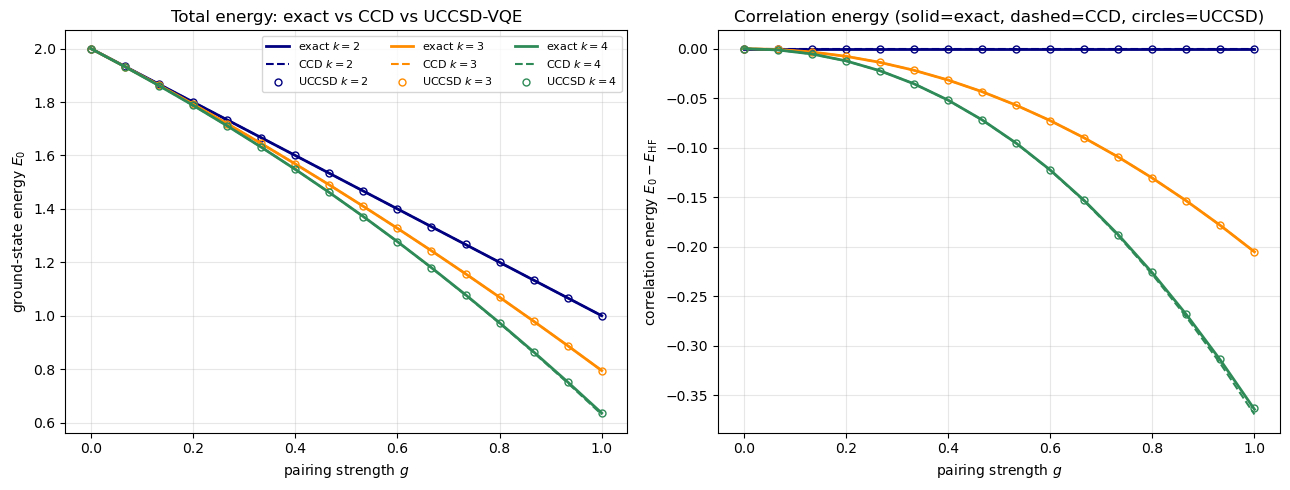

CCD is exact for k=2,3 and slightly over-binds at k=4; UCCSD-VQE is exact for
k=2,3 and a tight variational upper bound at k=4 -- the three curves nearly overlap.


In [10]:
# Sweep g for the three methods at k = 2, 3, 4 (N = 4)
g_scan = np.linspace(0.0, 1.0, 16)
E_ex = {k: [] for k in (2,3,4)}; E_cc = {k: [] for k in (2,3,4)}; E_vq = {k: [] for k in (2,3,4)}
setups = {k: setup_uccsd(k, 4) for k in (2,3,4)}
t0 = time.time()
for k in (2,3,4):
    su = setups[k]
    for g in g_scan:
        E_ex[k].append(np.linalg.eigvalsh(pairing_seniority0_H(k, g, 4)[0])[0])
        E_cc[k].append(run_ccd(k, g, 4)[0])
        E_vq[k].append(uccsd_vqe(su, H_pairing_sparse(k, g, 4, su['states'], su['index']))[0])
    E_ex[k]=np.array(E_ex[k]); E_cc[k]=np.array(E_cc[k]); E_vq[k]=np.array(E_vq[k])
print(f"g-sweep (k=2,3,4) finished in {time.time()-t0:.1f} s")

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5))
colors = {2:'navy', 3:'darkorange', 4:'seagreen'}
for k in (2,3,4):
    c = colors[k]
    axL.plot(g_scan, E_ex[k], '-',  color=c, lw=2,             label=f'exact $k={k}$')
    axL.plot(g_scan, E_cc[k], '--', color=c, lw=1.5,           label=f'CCD $k={k}$')
    axL.plot(g_scan, E_vq[k], 'o',  color=c, ms=5, mfc='none', label=f'UCCSD $k={k}$')
axL.set_xlabel('pairing strength $g$'); axL.set_ylabel('ground-state energy $E_0$')
axL.set_title('Total energy: exact vs CCD vs UCCSD-VQE'); axL.legend(ncol=3, fontsize=8); axL.grid(alpha=0.3)
for k in (2,3,4):
    c = colors[k]
    axR.plot(g_scan, E_ex[k]-E_HF(4, g_scan), '-',  color=c, lw=2)
    axR.plot(g_scan, E_cc[k]-E_HF(4, g_scan), '--', color=c, lw=1.5)
    axR.plot(g_scan, E_vq[k]-E_HF(4, g_scan), 'o',  color=c, ms=5, mfc='none')
axR.set_xlabel('pairing strength $g$'); axR.set_ylabel(r'correlation energy $E_0-E_{\rm HF}$')
axR.set_title('Correlation energy (solid=exact, dashed=CCD, circles=UCCSD)'); axR.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("CCD is exact for k=2,3 and slightly over-binds at k=4; UCCSD-VQE is exact for")
print("k=2,3 and a tight variational upper bound at k=4 -- the three curves nearly overlap.")

---
## 7  Scaling to $k=8$ with Trotterised UCCSD

Because the Trotterised ansatz never forms a dense operator, the *same* solver runs far
beyond the pedagogical sizes.  Keeping $N=4$, we scan $k=2,\dots,8$; at $k=8$ this is a
16-qubit problem solved inside the $\binom{16}{4}=1820$-dimensional sector.

 k qubits  dimFCI        FCI        CCD      UCCSD     U-FCI   CCD-FCI  #par
------------------------------------------------------------------------------------
 2      4       1   1.000000   1.000000   1.000000  +0.0e+00  +0.0e+00     0
 3      6      15   0.794697   0.794697   0.794697  +0.0e+00  +1.4e-13     8
 4      8      70   0.635548   0.630443   0.636987  +1.4e-03  -5.1e-03    26
 5     10     210   0.497768   0.484977   0.501278  +3.5e-03  -1.3e-02    54
 6     12     495   0.372664   0.350058   0.378719  +6.1e-03  -2.3e-02    92
 7     14    1001   0.256052   0.221608   0.265052  +9.0e-03  -3.4e-02   140
 8     16    1820   0.145559   0.097263   0.157856  +1.2e-02  -4.8e-02   198

UCCSD stays variational (>= FCI); CCD over-binds (< FCI).


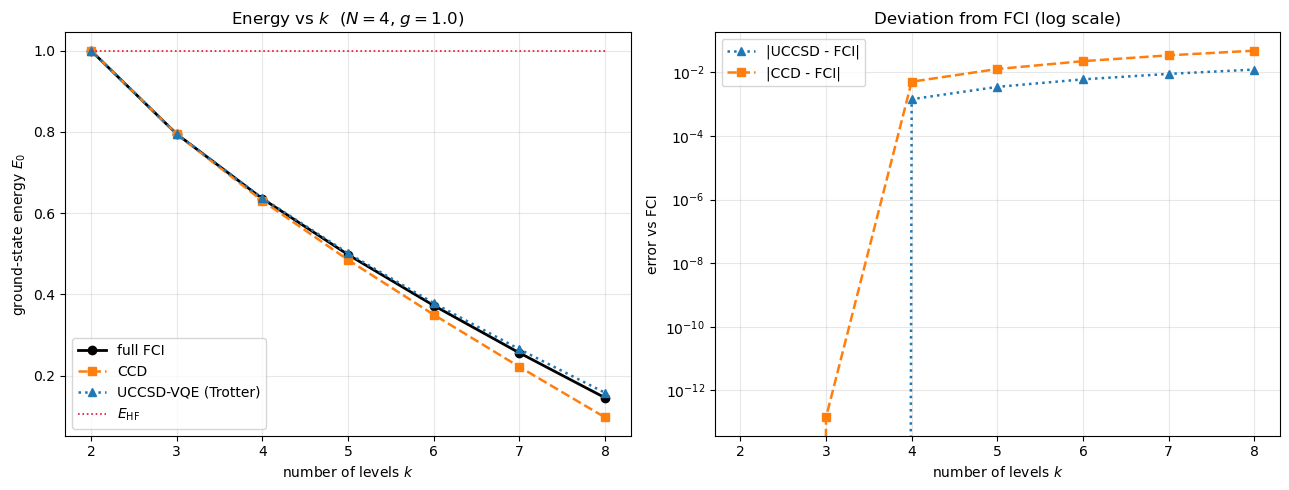

At k=8 (16 qubits): UCCSD-FCI = +1.23e-02,  CCD-FCI = -4.83e-02


 7     14    1001   0.256052   0.221608   0.265052  +9.0e-03  -3.4e-02   140


 8     16    1820   0.145559   0.097263   0.157856  +1.2e-02  -4.8e-02   198

UCCSD stays variational (>= FCI); CCD over-binds (< FCI).


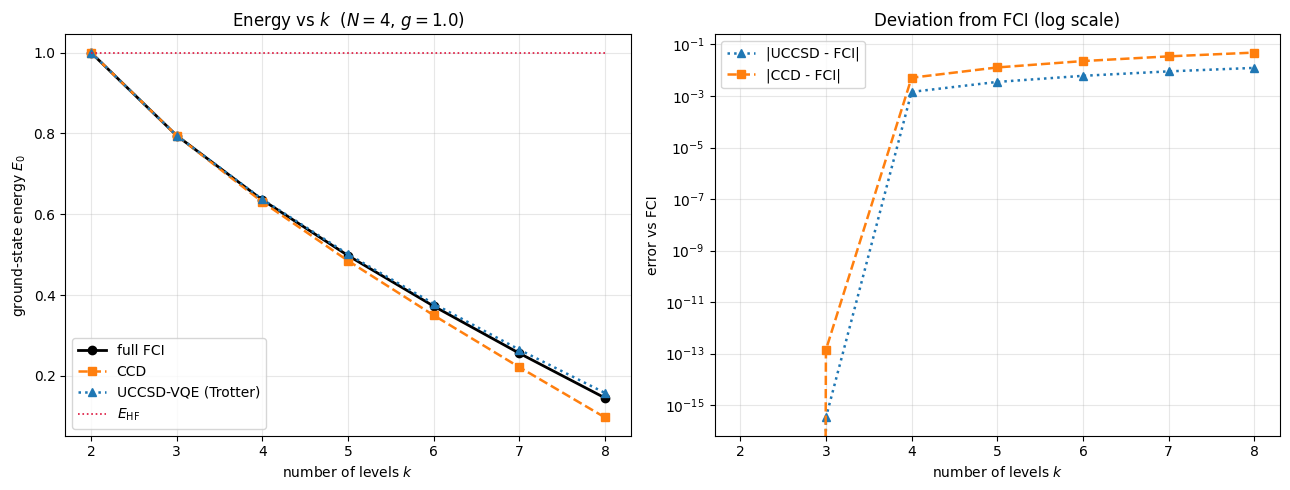

At k=8 (16 qubits): UCCSD-FCI = +1.23e-02,  CCD-FCI = -4.83e-02


In [11]:
N = 4; g = 1.0; ks = [2,3,4,5,6,7,8]; rows = []
print(f"{'k':>2} {'qubits':>6} {'dimFCI':>7} {'FCI':>10} {'CCD':>10} {'UCCSD':>10} "
      f"{'U-FCI':>9} {'CCD-FCI':>9} {'#par':>5}")
print("-"*84)
for k in ks:
    su = setup_uccsd(k, N); H = H_pairing_sparse(k, g, N, su['states'], su['index'])
    e_fci = fci_ground(H); e_ccd, _ = run_ccd(k, g, N); e_u, _, _, _ = uccsd_vqe(su, H)
    rows.append((k, 2*k, su['M'], e_fci, e_ccd, e_u, su['P']))
    print(f"{k:>2} {2*k:>6} {su['M']:>7} {e_fci:>10.6f} {e_ccd:>10.6f} {e_u:>10.6f} "
          f"{e_u-e_fci:>+9.1e} {e_ccd-e_fci:>+9.1e} {su['P']:>5}")
print("\nUCCSD stays variational (>= FCI); CCD over-binds (< FCI).")

ks_a=np.array([r[0] for r in rows]); e_fci_a=np.array([r[3] for r in rows])
e_ccd_a=np.array([r[4] for r in rows]); e_u_a=np.array([r[5] for r in rows])
fig,(axL,axR)=plt.subplots(1,2,figsize=(13,5))
axL.plot(ks_a,e_fci_a,'k-o',lw=2,label='full FCI')
axL.plot(ks_a,e_ccd_a,'C1--s',lw=1.8,label='CCD')
axL.plot(ks_a,e_u_a,'C0:^',lw=1.8,label='UCCSD-VQE (Trotter)')
axL.plot(ks_a,[E_HF(N,g)]*len(ks_a),color='crimson',ls=':',lw=1.2,label=r'$E_{\rm HF}$')
axL.set_xlabel('number of levels $k$'); axL.set_ylabel('ground-state energy $E_0$')
axL.set_title(f'Energy vs $k$  ($N={N}$, $g={g}$)'); axL.legend(); axL.grid(alpha=0.3)
axR.semilogy(ks_a,np.abs(e_u_a-e_fci_a),'C0:^',lw=1.8,label='|UCCSD - FCI|')
axR.semilogy(ks_a,np.abs(e_ccd_a-e_fci_a),'C1--s',lw=1.8,label='|CCD - FCI|')
axR.set_xlabel('number of levels $k$'); axR.set_ylabel('error vs FCI')
axR.set_title('Deviation from FCI (log scale)'); axR.legend(); axR.grid(alpha=0.3,which='both')
plt.tight_layout(); plt.show()
print(f"At k=8 (16 qubits): UCCSD-FCI = {e_u_a[-1]-e_fci_a[-1]:+.2e},  CCD-FCI = {e_ccd_a[-1]-e_fci_a[-1]:+.2e}")

Both correlated methods recover most of the correlation energy.  UCCSD remains a
variational upper bound whose error grows slowly with $k$ (from $\sim\!10^{-3}$ at $k=4$
to $\sim\!10^{-2}$ at $k=8$), while CCD over-binds with a larger-magnitude error.

---
## 8  Effect of the number of Trotter steps

The product ansatz is *first-order* Trotter.  Repeating the product $n_{\rm Trotter}$
times (each angle rescaled by $1/n_{\rm Trotter}$ and re-optimised) tests whether the
Trotter splitting itself limits accuracy.

In [12]:
k_t, N_t = 6, 4
su_t = setup_uccsd(k_t, N_t); H_t = H_pairing_sparse(k_t, 1.0, N_t, su_t['states'], su_t['index'])
e_fci_t = fci_ground(H_t)
print(f"Trotter-step convergence at k={k_t}, N={N_t}, g=1   (FCI = {e_fci_t:.6f})")
print("-"*52)
for nt in (1, 2, 3):
    t0 = time.time(); e_u, _, _, _ = uccsd_vqe(su_t, H_t, n_trotter=nt)
    print(f"  n_Trotter = {nt}:  E_UCCSD = {e_u:.6f}   E-FCI = {e_u-e_fci_t:+.2e}   ({time.time()-t0:.1f}s)")
print("\nThe energy is essentially flat in n_Trotter: first-order Trotter is already converged.")
print("The residual gap to FCI is the singles-and-doubles *truncation* error, not Trotter error.")

Trotter-step convergence at k=6, N=4, g=1   (FCI = 0.372664)
----------------------------------------------------
  n_Trotter = 1:  E_UCCSD = 0.378719   E-FCI = +6.06e-03   (0.5s)
  n_Trotter = 2:  E_UCCSD = 0.378797   E-FCI = +6.13e-03   (1.4s)
  n_Trotter = 3:  E_UCCSD = 0.378795   E-FCI = +6.13e-03   (3.1s)

The energy is essentially flat in n_Trotter: first-order Trotter is already converged.
The residual gap to FCI is the singles-and-doubles *truncation* error, not Trotter error.


  n_Trotter = 1:  E_UCCSD = 0.378719   E-FCI = +6.06e-03   (0.6s)


  n_Trotter = 2:  E_UCCSD = 0.378797   E-FCI = +6.13e-03   (2.2s)


  n_Trotter = 3:  E_UCCSD = 0.378795   E-FCI = +6.13e-03   (4.8s)

The energy is essentially flat in n_Trotter: first-order Trotter is already converged.
The residual gap to FCI is the singles-and-doubles *truncation* error, not Trotter error.


---
## 9  Varying the number of particles

Nothing is tied to $N=4$.  Fixing $k=6$, we sweep the (even) particle number
$N=2,4,6,8$ and compare UCCSD–VQE with full FCI and CCD.

In [13]:
k_v = 6
print(f"Varying N at k={k_v}, g=1")
print(f"  {'N':>2} {'pairs':>5} {'dimFCI':>7} {'FCI':>11} {'CCD':>11} {'UCCSD':>11} {'U-FCI':>9}")
print("  " + "-"*64)
for N_v in (2, 4, 6, 8):
    su = setup_uccsd(k_v, N_v); H_v = H_pairing_sparse(k_v, 1.0, N_v, su['states'], su['index'])
    e_fci = fci_ground(H_v); e_ccd, _ = run_ccd(k_v, 1.0, N_v); e_u, _, _, _ = uccsd_vqe(su, H_v)
    print(f"  {N_v:>2} {N_v//2:>5} {su['M']:>7} {e_fci:>11.6f} {e_ccd:>11.6f} {e_u:>11.6f} {e_u-e_fci:>+9.1e}")
print("\nN=2 (one pair) is reproduced exactly; for N>=4 UCCSD is a tight variational bound.")

Varying N at k=6, g=1
   N pairs  dimFCI         FCI         CCD       UCCSD     U-FCI
  ----------------------------------------------------------------
   2     1      66   -0.906337   -0.906337   -0.906337  -2.2e-15
   4     2     495    0.372664    0.350058    0.378719  +6.1e-03
   6     3     924    3.801528    3.768061    3.809807  +8.3e-03
   8     4     495    9.372664    9.350058    9.378308  +5.6e-03

N=2 (one pair) is reproduced exactly; for N>=4 UCCSD is a tight variational bound.


   2     1      66   -0.906337   -0.906337   -0.906337  -1.6e-15


   4     2     495    0.372664    0.350058    0.378719  +6.1e-03


   6     3     924    3.801528    3.768061    3.809807  +8.3e-03


   8     4     495    9.372664    9.350058    9.378308  +5.6e-03

N=2 (one pair) is reproduced exactly; for N>=4 UCCSD is a tight variational bound.


---
## 10  Summary

We built a single, coherent treatment of the constant-pairing model spanning three
methods and a wide range of $(k,N,g)$:

* **References.** Exact diagonalisation in the seniority-zero pair basis (the $6\times6$
  `week47.ipynb` matrix at $k=4$), shown to equal the full $N$-particle FCI, and the
  classical CCD solver — both generalised to arbitrary $(k,N)$.

* **Qubit encoding.** The Jordan–Wigner mapping in two representations: the explicit dense
  $2^{2k}$ Hamiltonian for transparency at small $k$, and a Fock-basis bitstring /
  fixed-$N$-sector representation for scaling.

* **Trotterised UCCSD–VQE.** The unitary coupled-cluster ansatz is applied the way a
  quantum computer would run it — as a *product* of single-excitation unitaries
  (first-order Trotter), each a set of disjoint $2\times2$ plane rotations on the Fock
  basis. This avoids any dense exponential and carries the *same* solver from $k=2$ to
  $k=8$ (16 qubits) and to any even $N$. The exact product gradient (equivalent to the
  generalised parameter-shift rule) drives an L-BFGS-B optimisation from
  $|\Phi_{\rm HF}\rangle$.

**Findings.**
* For $k=2$ the basis is a single determinant: all methods give $E_{\rm HF}=2-g$.
* Singles vanish identically — pairing correlations are carried entirely by the doubles,
  which is why the classical theory is coupled-cluster *doubles*.
* The full $N=4$ FCI lies in the no-broken-pair sector, so the VQE targets the same state
  as the exact diagonalisation.
* UCCSD–VQE is variational and tracks FCI closely; its error grows slowly with $k$
  ($\sim\!10^{-3}$ at $k=4$ to $\sim\!10^{-2}$ at $k=8$), while CCD over-binds with a
  larger-magnitude error. First-order Trotter is already converged, so the residual is the
  genuine singles-and-doubles truncation error.

The result is one notebook that runs from a single pair basis to a 16-qubit calculation
with the same Trotterised quantum-algorithm machinery throughout, benchmarked at every
step against exact diagonalisation and CCD.